In [1]:
# Cellule 1 — Config & Imports

In [2]:
# ══════════════════════════════════════════════════════════════
#  NOTEBOOK 03 — ENTRAÎNEMENT, ÉVALUATION, PERFORMANCES
#  Un seul paramètre à changer entre les bases
# ══════════════════════════════════════════════════════════════

# ── Seul paramètre à modifier ─────────────────────────────────
BASE_NAME     = "STE_NGDM"
PARETO_SEUIL  = 0.80    # top articles représentant 80% des sorties
TEST_RATIO    = 0.20    # 20% pour le test
CONTAMINATION = 0.05    # Isolation Forest
RF_ESTIMATORS = 100     # Random Forest

# ── Chemins ───────────────────────────────────────────────────
DATA_DIR  = f"../../output/{BASE_NAME}/data_clean/"
MODEL_DIR = f"../../models/{BASE_NAME}/"
PERF_DIR  = f"../../output/{BASE_NAME}/performance/"
PLOT_DIR  = f"../../output/{BASE_NAME}/plots/"

import os
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PERF_DIR,  exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

# ── Manipulation données ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# # ── Prophet ───────────────────────────────────────────────────
# from prophet import Prophet
# import holidays

# ── Random Forest ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Isolation Forest ──────────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── K-Means ───────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Sauvegarde modèles ────────────────────────────────────────
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Style graphes ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi']     = 120

print("✅ Imports OK")
print(f"📦 Base ciblée : {BASE_NAME}")
print(f"📁 Data        : {DATA_DIR}")
print(f"📁 Models      : {MODEL_DIR}")

✅ Imports OK
📦 Base ciblée : STE_NGDM
📁 Data        : ../../output/STE_NGDM/data_clean/
📁 Models      : ../../models/STE_NGDM/


In [3]:
# Cellule 2 — Chargement des datasets

In [4]:
df_prophet = pd.read_csv(f"{DATA_DIR}df_prophet.csv",  parse_dates=['ds'])
df_rf      = pd.read_csv(f"{DATA_DIR}df_rf.csv",       parse_dates=['DateJour'])
df_iforest = pd.read_csv(f"{DATA_DIR}df_iforest.csv",  parse_dates=['DateJour'])
df_kmeans  = pd.read_csv(f"{DATA_DIR}df_kmeans.csv",   index_col=0)

print("- Datasets chargés")
print(f"   df_prophet  : {len(df_prophet):,} lignes | {df_prophet['AR_Ref'].nunique()} articles")
print(f"   df_rf       : {len(df_rf):,} lignes | {df_rf['AR_Ref'].nunique()} articles")
print(f"   df_iforest  : {len(df_iforest):,} lignes | {df_iforest['AR_Ref'].nunique()} articles")
print(f"   df_kmeans   : {df_kmeans.shape[0]} articles × {df_kmeans.shape[1]} mois")

- Datasets chargés
   df_prophet  : 128,172 lignes | 132 articles
   df_rf       : 128,040 lignes | 132 articles
   df_iforest  : 128,172 lignes | 132 articles
   df_kmeans   : 132 articles × 33 mois


In [5]:
# Cellule 3 — Sélection top articles Pareto (Prophet)

In [6]:
# ── Calculer le top articles dynamiquement ────────────────────
# Pas de nombre en dur — calculé depuis PARETO_SEUIL

by_article = df_prophet.groupby('AR_Ref')['y'].sum().sort_values(ascending=False)
cumul_pct  = by_article.cumsum() / by_article.sum()
top_articles = cumul_pct[cumul_pct <= PARETO_SEUIL].index.tolist()

# Ajouter le premier article qui dépasse le seuil
idx_suivant = len(top_articles)
if idx_suivant < len(cumul_pct):
    top_articles.append(cumul_pct.index[idx_suivant])

print(f"- Top articles Pareto ({PARETO_SEUIL*100:.0f}%)")
print(f"   Nb articles sélectionnés : {len(top_articles)}")
print(f"   Sur total                : {df_prophet['AR_Ref'].nunique()}")
print(f"   Représentent             : {by_article[top_articles].sum()/by_article.sum()*100:.1f}% des sorties")

- Top articles Pareto (80%)
   Nb articles sélectionnés : 24
   Sur total                : 132
   Représentent             : 80.5% des sorties


In [7]:
# Cellule 4 — Jours fériés marocains

In [8]:
# # ── Jours fériés Maroc ────────────────────────────────────────
# # Calculés dynamiquement sur toute la période des données

# annees = df_prophet['ds'].dt.year.unique().tolist()

# ma_holidays = holidays.Morocco(years=annees)
# df_holidays = pd.DataFrame({
#     'ds'      : pd.to_datetime(list(ma_holidays.keys())),
#     'holiday' : list(ma_holidays.values())
# })
# df_holidays = df_holidays.sort_values('ds').reset_index(drop=True)

# print(f"- Jours fériés marocains chargés")
# print(f"   Années couvertes : {min(annees)} → {max(annees)}")
# print(f"   Nb jours fériés  : {len(df_holidays)}")

In [9]:
# Cellule 5 — Entraînement Prophet

In [10]:
# resultats_prophet = []

# for ar_ref in top_articles:

#     # ── Données de l'article ──────────────────────────────────
#     df_art = df_prophet[df_prophet['AR_Ref'] == ar_ref][['ds', 'y']].copy()
#     df_art = df_art.sort_values('ds').reset_index(drop=True)

#     # ── Split train/test : 80% train, 20% test ────────────────
#     n_test   = max(30, int(len(df_art) * TEST_RATIO))
#     df_train = df_art.iloc[:-n_test]
#     df_test  = df_art.iloc[-n_test:]

#     # ── Configurer Prophet ────────────────────────────────────
#     model = Prophet(
#         weekly_seasonality      = True,
#         yearly_seasonality      = True,
#         changepoint_prior_scale = 0.05,
#         holidays                = df_holidays
#     )
#     model.fit(df_train)

#     # ── Prédire sur la période de test ────────────────────────
#     future   = model.make_future_dataframe(periods=n_test)
#     forecast = model.predict(future)

#     # Prendre les n_test dernières prédictions
#     forecast_test = forecast.tail(n_test).reset_index(drop=True)
#     df_test       = df_test.reset_index(drop=True)

#     y_true = df_test['y'].values
#     y_pred = np.maximum(forecast_test['yhat'].values, 0)

#     # ── Métriques ─────────────────────────────────────────────
#     mae  = mean_absolute_error(y_true, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))

#     # MAPE : uniquement sur les jours avec sortie > 0
#     mask = y_true > 0
#     if mask.sum() > 0:
#         mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
#     else:
#         mape = np.nan

#     resultats_prophet.append({
#         'AR_Ref'  : ar_ref,
#         'MAE'     : round(mae,  2),
#         'RMSE'    : round(rmse, 2),
#         'MAPE'    : round(mape, 2) if not np.isnan(mape) else np.nan,
#         'nb_train': len(df_train),
#         'nb_test' : n_test
#     })

#     # ── Sauvegarder le modèle ─────────────────────────────────
#     with open(f"{MODEL_DIR}prophet_{ar_ref}.pkl", 'wb') as f:
#         pickle.dump(model, f)

#     mape_str = f"{mape:.1f}%" if not np.isnan(mape) else "N/A"
#     print(f"   {ar_ref:15s} | MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_str}")

# df_perf_prophet = pd.DataFrame(resultats_prophet)
# print(f"\n✅ Prophet : {len(top_articles)} modèles entraînés")
# print(f"   MAE moyen  : {df_perf_prophet['MAE'].mean():.1f}")
# print(f"   RMSE moyen : {df_perf_prophet['RMSE'].mean():.1f}")
# mape_valide = df_perf_prophet['MAPE'].dropna()
# if len(mape_valide) > 0:
#     print(f"   MAPE moyen : {mape_valide.mean():.1f}%  ({len(mape_valide)} articles)")
# else:
#     print(f"   MAPE moyen : N/A (tous les articles ont y=0 sur le test)")

In [11]:
# ══════════════════════════════════════════════════════════════
#  CELLULE 5 — Prévision sorties J+7 / J+30
#  AutoARIMA (statsforecast) — remplace Prophet
#  Même structure : MAE, RMSE, MAPE + sauvegarde pickle
# ══════════════════════════════════════════════════════════════
 
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle, numpy as np
 
resultats_prophet = []   # ← nom conservé pour compatibilité avec cellule 6+
 
for ar_ref in top_articles:
 
    # ── Données de l'article ──────────────────────────────────
    df_art = df_prophet[df_prophet['AR_Ref'] == ar_ref][['ds', 'y']].copy()
    df_art = df_art.sort_values('ds').reset_index(drop=True)
 
    # ── Vérification minimum de données ──────────────────────
    if len(df_art) < 60:
        print(f"   {ar_ref:15s} | ⚠️  Pas assez de données ({len(df_art)} lignes) — ignoré")
        continue
 
    # ── Split train/test : 80% train, 20% test ────────────────
    n_test   = max(30, int(len(df_art) * TEST_RATIO))
    df_train = df_art.iloc[:-n_test].copy()
    df_test  = df_art.iloc[-n_test:].copy()
 
    # ── Format statsforecast : unique_id + ds + y ─────────────
    df_sf = df_train.rename(columns={'ds': 'ds', 'y': 'y'}).copy()
    df_sf['unique_id'] = ar_ref
 
    # ── Modèle AutoARIMA ─────────────────────────────────────
    model = StatsForecast(
        models=[AutoARIMA(
            season_length=7,      # saisonnalité hebdomadaire
            approximation=True,   # plus rapide
        )],
        freq='D',                 # fréquence journalière
        n_jobs=1,
    )
 
    # ── Entraînement ─────────────────────────────────────────
    model.fit(df_sf)
 
    # ── Prédiction sur n_test jours ──────────────────────────
    forecast = model.predict(h=n_test)
 
    y_true = df_test['y'].values
    y_pred = np.maximum(forecast['AutoARIMA'].values, 0)  # pas de négatif
 
    # ── Métriques ─────────────────────────────────────────────
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
 
    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
 
    resultats_prophet.append({
        'AR_Ref'  : ar_ref,
        'MAE'     : round(mae,  2),
        'RMSE'    : round(rmse, 2),
        'MAPE'    : round(mape, 2) if not np.isnan(mape) else np.nan,
        'nb_train': len(df_train),
        'nb_test' : n_test
    })
 
    # ── Sauvegarder le modèle ─────────────────────────────────
    with open(f"{MODEL_DIR}prophet_{ar_ref}.pkl", 'wb') as f:
        pickle.dump(model, f)
 
    mape_str = f"{mape:.1f}%" if not np.isnan(mape) else "N/A"
    print(f"   {ar_ref:15s} | MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_str}")
 
df_perf_prophet = pd.DataFrame(resultats_prophet)
print(f"\n✅ AutoARIMA : {len(df_perf_prophet)} modèles entraînés")
print(f"   MAE moyen  : {df_perf_prophet['MAE'].mean():.1f}")
print(f"   RMSE moyen : {df_perf_prophet['RMSE'].mean():.1f}")
mape_valide = df_perf_prophet['MAPE'].dropna()
if len(mape_valide) > 0:
    print(f"   MAPE moyen : {mape_valide.mean():.1f}%  ({len(mape_valide)} articles)")
else:
    print(f"   MAPE moyen : N/A")

   MHCH003         | MAE=0.0 | RMSE=0.0 | MAPE=N/A
   PHCH026         | MAE=0.1 | RMSE=0.1 | MAPE=N/A
   PPRF006         | MAE=0.4 | RMSE=0.4 | MAPE=N/A
   PPRF007         | MAE=2.2 | RMSE=2.2 | MAPE=N/A
   PPRF004         | MAE=0.0 | RMSE=0.0 | MAPE=N/A
   PPRF047         | MAE=0.6 | RMSE=0.6 | MAPE=N/A
   MJTM002         | MAE=5.4 | RMSE=5.4 | MAPE=N/A
   PPRF050         | MAE=1.0 | RMSE=1.0 | MAPE=N/A
   PPRF028         | MAE=0.0 | RMSE=0.0 | MAPE=N/A
   PFRF001         | MAE=51.1 | RMSE=51.1 | MAPE=N/A
   PPRF046         | MAE=0.0 | RMSE=0.0 | MAPE=N/A
   PPRF045         | MAE=1.3 | RMSE=1.4 | MAPE=N/A
   1000664         | MAE=31.1 | RMSE=31.2 | MAPE=N/A
   1000723         | MAE=17.1 | RMSE=17.1 | MAPE=N/A
   MVRM001         | MAE=1.4 | RMSE=1.4 | MAPE=N/A
   1000634         | MAE=0.1 | RMSE=0.1 | MAPE=N/A
   PPRF038         | MAE=0.0 | RMSE=0.0 | MAPE=N/A
   PPRF049         | MAE=0.0 | RMSE=0.0 | MAPE=N/A
   1000591         | MAE=26.4 | RMSE=26.5 | MAPE=N/A
   PFRF002         | MA

In [12]:
# Cellule 6 — Graphes Prophet (top 3 articles)

In [13]:
# # ── Tracer les 3 meilleurs articles ───────────────────────────
# top3 = df_perf_prophet.nsmallest(3, 'MAPE')['AR_Ref'].tolist()

# for ar_ref in top3:
#     df_art   = df_prophet[df_prophet['AR_Ref'] == ar_ref][['ds','y']].sort_values('ds')
#     cutoff   = df_art['ds'].max() - pd.Timedelta(days=int(len(df_art) * TEST_RATIO))
#     df_train = df_art[df_art['ds'] <= cutoff]
#     df_test  = df_art[df_art['ds'] >  cutoff]

#     with open(f"{MODEL_DIR}prophet_{ar_ref}.pkl", 'rb') as f:
#         model = pickle.load(f)

#     future   = model.make_future_dataframe(periods=len(df_test) + 30)
#     forecast = model.predict(future)

#     fig, ax = plt.subplots(figsize=(14, 4))
#     ax.plot(df_train['ds'], df_train['y'], color='steelblue',  label='Train')
#     ax.plot(df_test['ds'],  df_test['y'],  color='green',      label='Réel (test)')
#     ax.plot(forecast['ds'], forecast['yhat'], color='orange', linestyle='--', label='Prédit')
#     ax.fill_between(forecast['ds'],
#                     forecast['yhat_lower'],
#                     forecast['yhat_upper'],
#                     alpha=0.2, color='orange', label='Intervalle confiance')
#     ax.set_title(f'Prophet — {ar_ref} | MAPE={df_perf_prophet[df_perf_prophet["AR_Ref"]==ar_ref]["MAPE"].values[0]:.1f}%')
#     ax.set_xlabel('Date')
#     ax.set_ylabel('TotalSortie')
#     ax.legend()
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
#     plt.tight_layout()
#     plt.savefig(f"{PLOT_DIR}prophet_{ar_ref}.png", dpi=120, bbox_inches='tight')
#     plt.show()

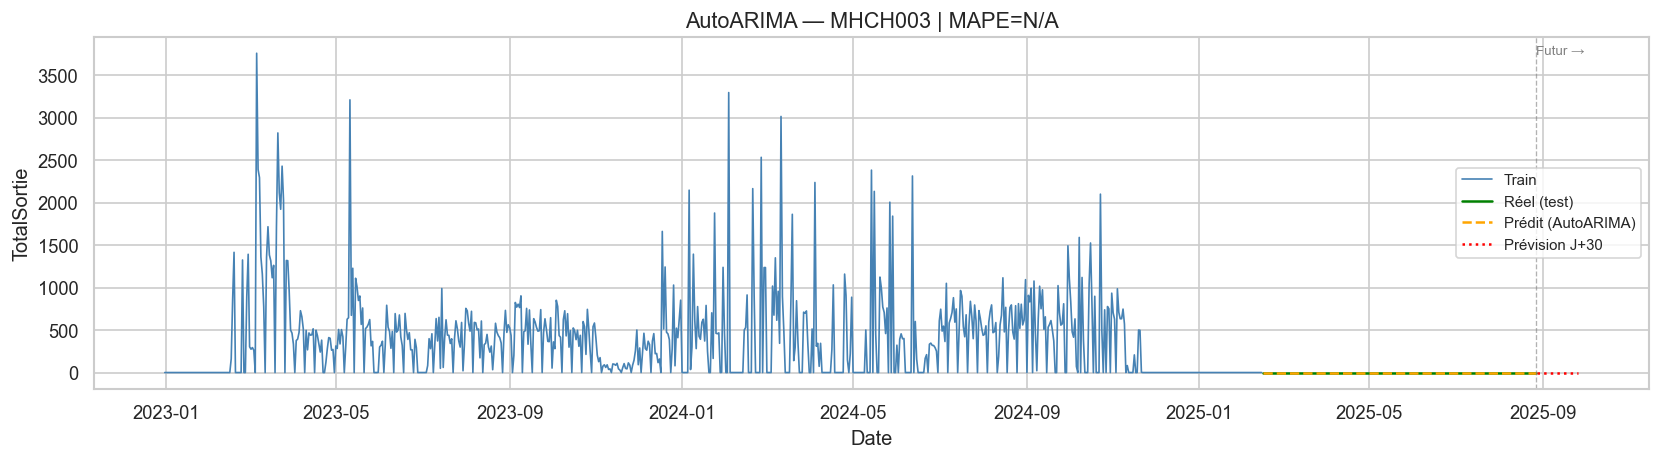

   ✅ MHCH003 — graphe sauvegardé


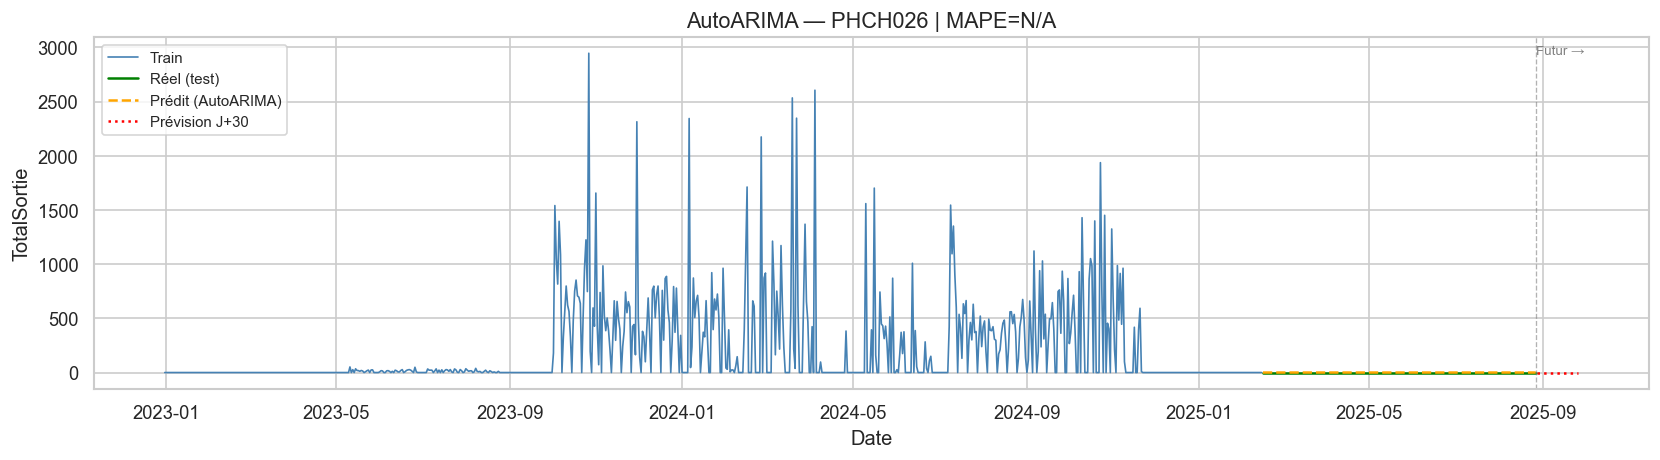

   ✅ PHCH026 — graphe sauvegardé


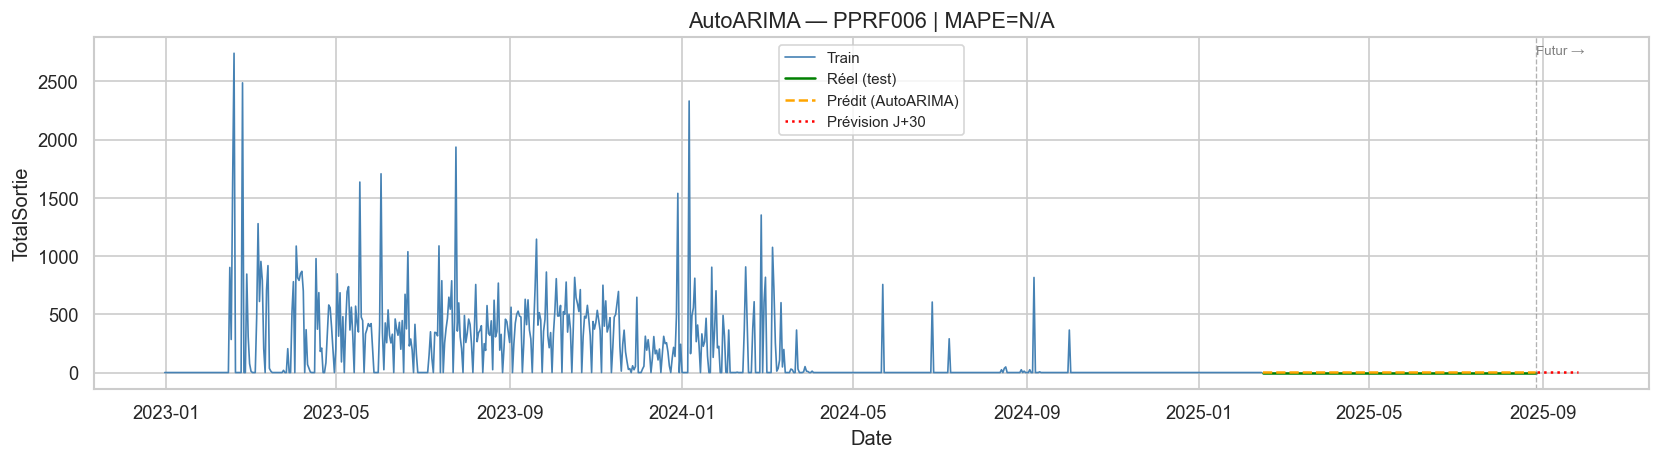

   ✅ PPRF006 — graphe sauvegardé


In [14]:
# ══════════════════════════════════════════════════════════════
#  CELLULE 6 — Graphes AutoARIMA (top 3 articles)
#  Correction : predict() sans unique_id après rechargement pkl
# ══════════════════════════════════════════════════════════════

top3 = df_perf_prophet.nsmallest(3, 'MAPE')['AR_Ref'].tolist()

for ar_ref in top3:

    # ── Données de l'article ──────────────────────────────────
    df_art  = df_prophet[df_prophet['AR_Ref'] == ar_ref][['ds','y']]\
                .sort_values('ds').reset_index(drop=True)
    n_test  = max(30, int(len(df_art) * TEST_RATIO))
    df_train = df_art.iloc[:-n_test].copy()
    df_test  = df_art.iloc[-n_test:].copy()

    # ── Recharger le modèle sauvegardé ───────────────────────
    with open(f"{MODEL_DIR}prophet_{ar_ref}.pkl", 'rb') as f:
        model = pickle.load(f)

    # ── Reconstruire le df au format statsforecast ────────────
    # OBLIGATOIRE après rechargement pickle :
    # le modèle a besoin du unique_id pour predict()
    df_sf_full = df_train.copy()
    df_sf_full['unique_id'] = ar_ref

    # Re-fit sur les données train pour restaurer le contexte
    model.fit(df_sf_full)

    # ── Prédire n_test + 30 jours (test + horizon futur) ─────
    forecast_ext = model.predict(h=n_test + 30, level=[])
    # level=[] → pas d'intervalle de confiance (évite une erreur statsforecast)

    y_pred_test = np.maximum(
        forecast_ext['AutoARIMA'].values[:n_test], 0
    )
    y_pred_futur = np.maximum(
        forecast_ext['AutoARIMA'].values[n_test:], 0
    )

    # ── Dates futures (J+1 → J+30 après la fin du test) ──────
    last_date   = df_test['ds'].max()
    dates_futur = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq='D'
    )

    # ── Métriques de l'article ────────────────────────────────
    mape_val = df_perf_prophet[
        df_perf_prophet['AR_Ref'] == ar_ref
    ]['MAPE'].values[0]
    mape_str = f"{mape_val:.1f}%" if not np.isnan(mape_val) else "N/A"

    # ── Graphe ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))

    # Données train
    ax.plot(df_train['ds'], df_train['y'],
            color='steelblue', linewidth=1, label='Train')

    # Données réelles test
    ax.plot(df_test['ds'], df_test['y'],
            color='green', linewidth=1.5, label='Réel (test)')

    # Prédictions sur la période test
    ax.plot(df_test['ds'], y_pred_test,
            color='orange', linestyle='--', linewidth=1.5,
            label='Prédit (AutoARIMA)')

    # Prédictions futures J+30
    ax.plot(dates_futur, y_pred_futur,
            color='red', linestyle=':', linewidth=1.5,
            label='Prévision J+30')

    # Ligne verticale séparant test / futur
    ax.axvline(x=last_date, color='gray',
               linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(last_date, ax.get_ylim()[1] * 0.95,
            'Futur →', fontsize=8, color='gray')

    ax.set_title(f'AutoARIMA — {ar_ref} | MAPE={mape_str}', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('TotalSortie')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}prophet_{ar_ref}.png",
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f"   ✅ {ar_ref} — graphe sauvegardé")

In [15]:
# Cellule 7 — Random Forest

In [16]:
# ── Features disponibles dynamiquement ───────────────────────
features_voulues = ['sortie_lag_1', 'sortie_lag_7', 'sortie_lag_30',
                    'rolling_mean_7', 'rolling_mean_30',
                    'StockFinal', 'jour_semaine', 'mois', 'trimestre']

features_rf = [col for col in features_voulues if col in df_rf.columns]
target_rf   = 'jours_avant_rupture'

print(f"Features utilisées : {features_rf}")

# ── Supprimer lignes sans target ──────────────────────────────
df_rf_clean = df_rf.dropna(subset=[target_rf] + features_rf).copy()
df_rf_clean = df_rf_clean.sort_values('DateJour').reset_index(drop=True)

print(f"Lignes après nettoyage : {len(df_rf_clean):,}")

# ── Split temporel ────────────────────────────────────────────
cutoff_idx = int(len(df_rf_clean) * (1 - TEST_RATIO))
train_rf   = df_rf_clean.iloc[:cutoff_idx]
test_rf    = df_rf_clean.iloc[cutoff_idx:]

X_train = train_rf[features_rf]
y_train = train_rf[target_rf]
X_test  = test_rf[features_rf]
y_test  = test_rf[target_rf]

# ── Normalisation ─────────────────────────────────────────────
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Entraînement ──────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators = RF_ESTIMATORS,
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train_s, y_train)

# ── Métriques ─────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test_s)
mae_rf    = mean_absolute_error(y_test, y_pred_rf)
rmse_rf   = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"\n✅ Random Forest entraîné")
print(f"   Train : {len(train_rf):,} lignes")
print(f"   Test  : {len(test_rf):,} lignes")
print(f"   MAE   : {mae_rf:.1f} jours")
print(f"   RMSE  : {rmse_rf:.1f} jours")

# ── Sauvegarder ───────────────────────────────────────────────
with open(f"{MODEL_DIR}rf_rupture.pkl", 'wb') as f:
    pickle.dump(rf_model, f)
with open(f"{MODEL_DIR}scaler_rf.pkl", 'wb') as f:
    pickle.dump(scaler, f)

print(f"✅ Modèles sauvegardés dans {MODEL_DIR}")

Features utilisées : ['sortie_lag_1', 'sortie_lag_7', 'sortie_lag_30', 'rolling_mean_7', 'rolling_mean_30', 'StockFinal', 'jour_semaine', 'mois', 'trimestre']
Lignes après nettoyage : 28,550

✅ Random Forest entraîné
   Train : 22,840 lignes
   Test  : 5,710 lignes
   MAE   : 2.1 jours
   RMSE  : 6.1 jours
✅ Modèles sauvegardés dans ../../models/STE_NGDM/


In [17]:
# Cellule 8 — Graphe feature importance RF

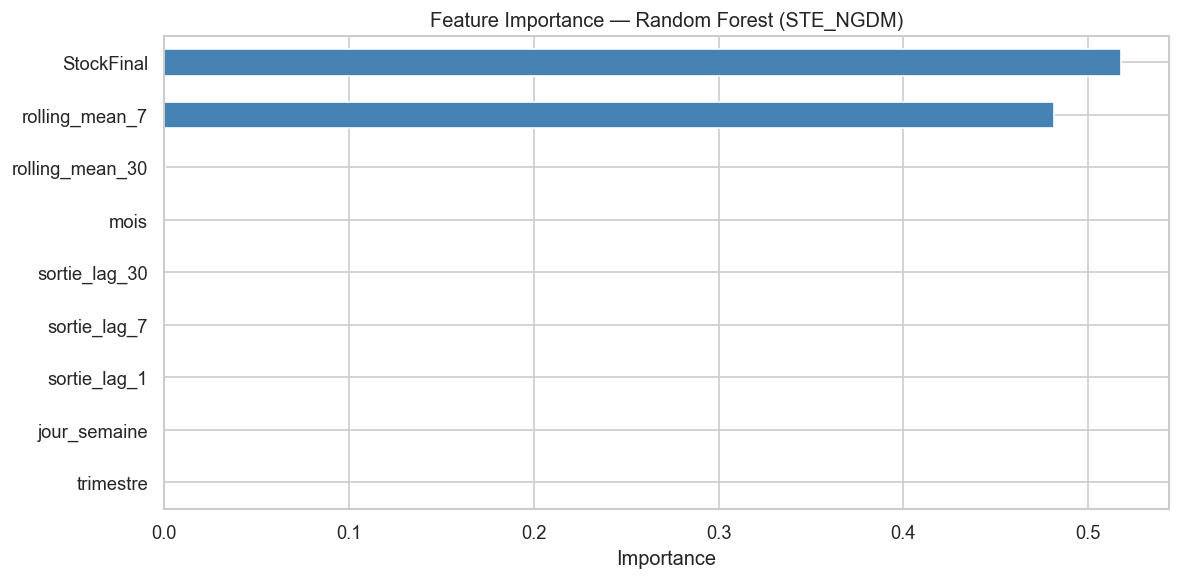

 Graphe sauvegardé : rf_feature_importance.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

importances = pd.Series(rf_model.feature_importances_, index=features_rf)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Feature Importance — Random Forest ({BASE_NAME})')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}rf_feature_importance.png", dpi=120, bbox_inches='tight')
plt.show()
print(" Graphe sauvegardé : rf_feature_importance.png")

In [19]:
# Cellule 9 — Isolation Forest

In [20]:
# ── Features disponibles dynamiquement ───────────────────────
features_voulues_if = ['TotalEntree', 'TotalSortie',
                        'ValeurEntree', 'ValeurSortie',
                        'StockFinal', 'jour_semaine', 'mois']

features_if = [col for col in features_voulues_if if col in df_iforest.columns]

print(f"Features utilisées : {features_if}")

X_if = df_iforest[features_if].fillna(0)

# ── Normalisation ─────────────────────────────────────────────
scaler_if = StandardScaler()
X_if_s    = scaler_if.fit_transform(X_if)

# ── Entraînement ──────────────────────────────────────────────
iforest = IsolationForest(
    contamination = CONTAMINATION,
    random_state  = 42,
    n_jobs        = -1
)
iforest.fit(X_if_s)

# ── Résultats ─────────────────────────────────────────────────
df_iforest['anomaly_score'] = iforest.decision_function(X_if_s)
df_iforest['is_anomalie']   = iforest.predict(X_if_s)
df_iforest['is_anomalie']   = df_iforest['is_anomalie'].map({1: 0, -1: 1})

nb_anomalies = df_iforest['is_anomalie'].sum()
print(f"\n✅ Isolation Forest entraîné")
print(f"   Lignes totales   : {len(df_iforest):,}")
print(f"   Anomalies détectées : {nb_anomalies} ({nb_anomalies/len(df_iforest)*100:.1f}%)")

# ── Top 20 anomalies ──────────────────────────────────────────
top_anomalies = df_iforest[df_iforest['is_anomalie'] == 1]\
    .sort_values('anomaly_score')\
    .head(20)[['DateJour', 'AR_Ref', 'TotalSortie', 'TotalEntree',
               'StockFinal', 'anomaly_score']]

print("\nTop 20 anomalies les plus sévères :")
print(top_anomalies.to_string(index=False))

# ── Sauvegarder ───────────────────────────────────────────────
with open(f"{MODEL_DIR}iforest_anomalies.pkl", 'wb') as f:
    pickle.dump(iforest, f)
with open(f"{MODEL_DIR}scaler_iforest.pkl", 'wb') as f:
    pickle.dump(scaler_if, f)

print(f"\n✅ Modèle sauvegardé : iforest_anomalies.pkl")

Features utilisées : ['TotalEntree', 'TotalSortie', 'ValeurEntree', 'ValeurSortie', 'StockFinal', 'jour_semaine', 'mois']

✅ Isolation Forest entraîné
   Lignes totales   : 128,172
   Anomalies détectées : 6409 (5.0%)

Top 20 anomalies les plus sévères :
  DateJour  AR_Ref  TotalSortie  TotalEntree  StockFinal  anomaly_score
2023-03-23 MHCH003      1921.60     20291.47    19495.49      -0.287002
2024-03-07 MHCH003      1350.51      7768.49    15759.94      -0.281838
2023-03-06 MHCH003      3758.33      7721.70    11339.23      -0.281266
2023-03-10 MHCH003      1160.42      7733.78    11866.07      -0.277274
2024-02-20 MHCH003      2164.70      7846.43     9118.40      -0.269909
2023-10-07 MHCH003       415.17      9768.69    16844.99      -0.269345
2024-03-13 MHCH003       492.51      7716.30    17158.07      -0.267740
2023-02-27 MHCH003       891.39      4846.12     9901.74      -0.264849
2023-03-28 MHCH003      1316.84     20447.95     5421.39      -0.263728
2024-02-03 MHCH003      3

In [21]:
# Cellule 10 — Graphe Isolation Forest

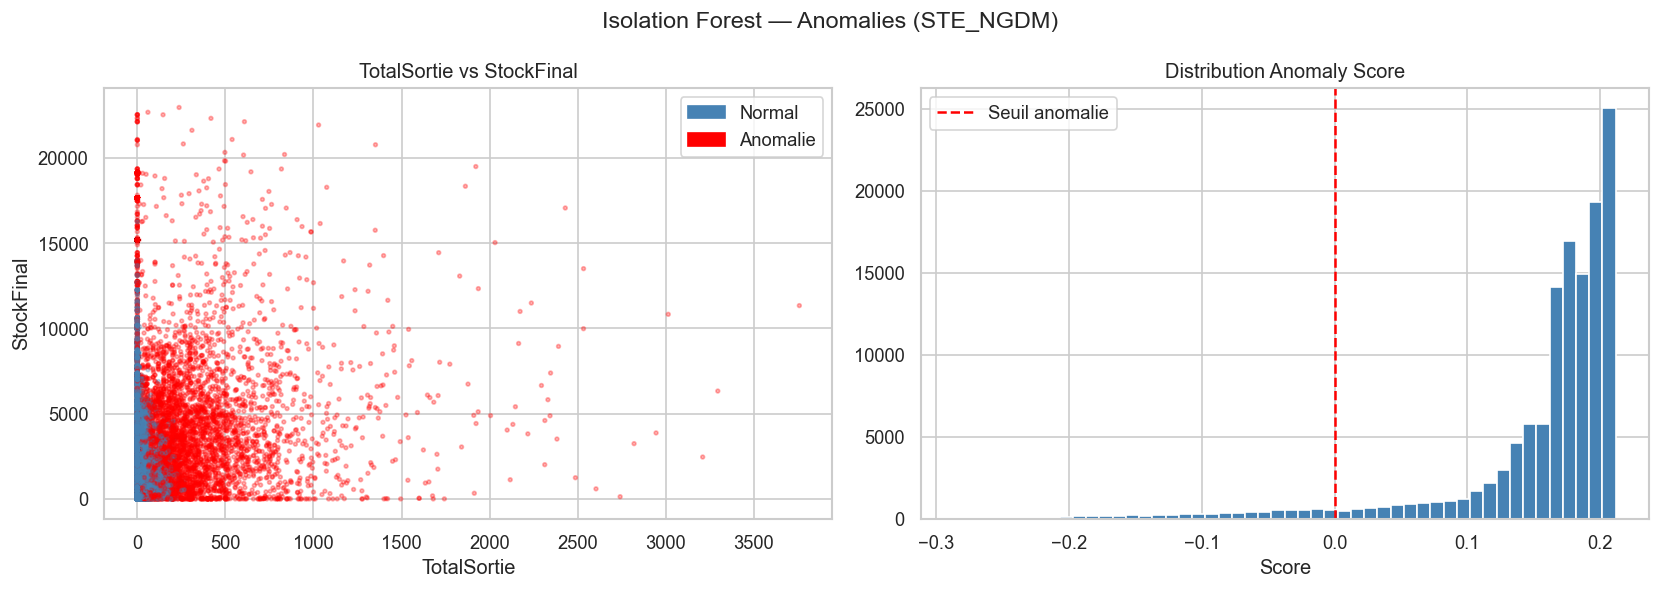

 Graphe sauvegardé : iforest_anomalies.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Isolation Forest — Anomalies ({BASE_NAME})', fontsize=14)

# ── Scatter TotalSortie vs StockFinal coloré par anomalie ─────
colors = df_iforest['is_anomalie'].map({0: 'steelblue', 1: 'red'})
axes[0].scatter(df_iforest['TotalSortie'],
                df_iforest['StockFinal'],
                c=colors, alpha=0.3, s=5)
axes[0].set_title('TotalSortie vs StockFinal')
axes[0].set_xlabel('TotalSortie')
axes[0].set_ylabel('StockFinal')

# Légende manuelle
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='steelblue', label='Normal'),
    Patch(color='red',       label='Anomalie')
])

# ── Distribution anomaly_score ────────────────────────────────
axes[1].hist(df_iforest['anomaly_score'], bins=50,
             color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', label='Seuil anomalie')
axes[1].set_title('Distribution Anomaly Score')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}iforest_anomalies.png", dpi=120, bbox_inches='tight')
plt.show()
print(" Graphe sauvegardé : iforest_anomalies.png")

In [23]:
# Cellule 11 — K-Means : méthode Elbow

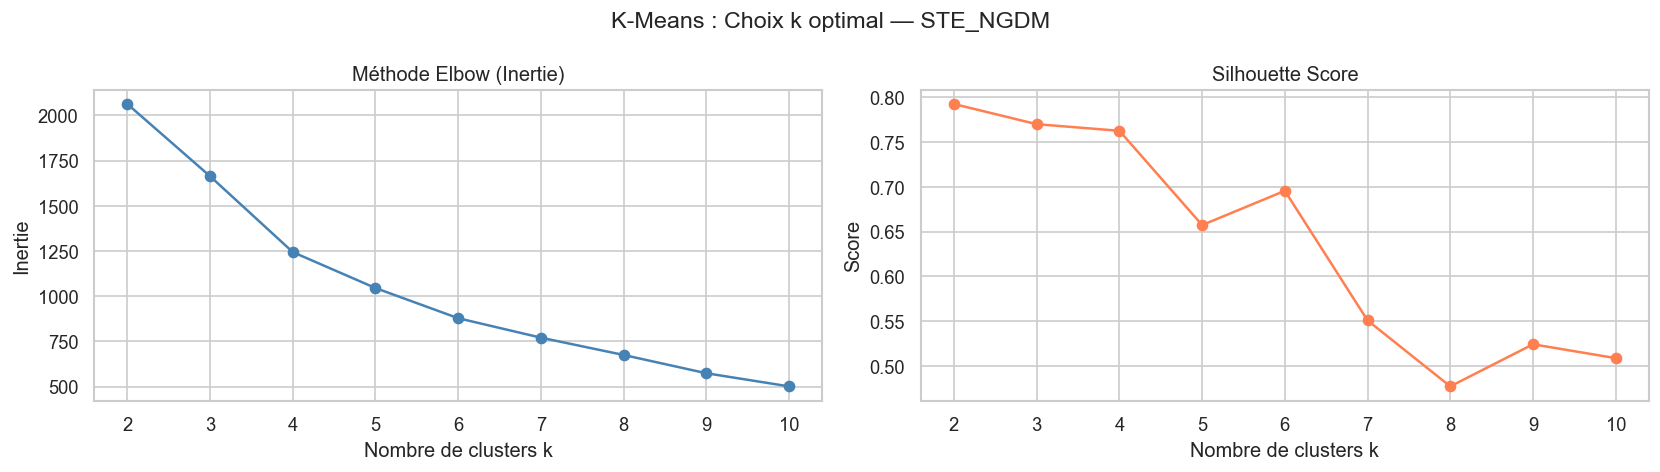

 k optimal détecté automatiquement : 2
   Silhouette score : 0.793


In [24]:
# ── Normalisation ─────────────────────────────────────────────
scaler_km  = StandardScaler()
X_km       = scaler_km.fit_transform(df_kmeans.fillna(0))

# ── Elbow : tester k=2 à 10 ───────────────────────────────────
k_range    = range(2, min(11, len(df_kmeans)))
inertias   = []
silhouettes = []

for k in k_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, labs))

# ── Graphe Elbow + Silhouette ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'K-Means : Choix k optimal — {BASE_NAME}', fontsize=14)

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Méthode Elbow (Inertie)')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')

axes[1].plot(list(k_range), silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}kmeans_elbow.png", dpi=120, bbox_inches='tight')
plt.show()

# ── k optimal = silhouette max ────────────────────────────────
k_optimal = list(k_range)[silhouettes.index(max(silhouettes))]
print(f" k optimal détecté automatiquement : {k_optimal}")
print(f"   Silhouette score : {max(silhouettes):.3f}")

In [25]:
# Cellule 12 — K-Means : entraînement

In [26]:
# ── Entraînement avec k optimal ───────────────────────────────
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
labels   = km_final.fit_predict(X_km)

df_kmeans_result            = df_kmeans.copy()
df_kmeans_result['cluster'] = labels

# ── Nommer les clusters automatiquement ───────────────────────
# Colonnes mois = toutes les colonnes sauf 'cluster'
cols_mois = [col for col in df_kmeans_result.columns if col != 'cluster']

sortie_par_cluster = df_kmeans_result.groupby('cluster')[cols_mois]\
    .mean().sum(axis=1).sort_values(ascending=False)

cluster_rank = sortie_par_cluster.index.tolist()

noms_disponibles = ['forte rotation', 'rotation moyenne',
                    'faible rotation', 'quasi-immobile']

# Adapter le nombre de noms au nombre de clusters
noms_clusters = {
    cluster: noms_disponibles[i] if i < len(noms_disponibles) else f'cluster_{i}'
    for i, cluster in enumerate(cluster_rank)
}

df_kmeans_result['segment'] = df_kmeans_result['cluster'].map(noms_clusters)

print(f" K-Means entraîné — k={k_optimal}")
print("\nRépartition par segment :")
for nom, grp in df_kmeans_result.groupby('segment'):
    print(f"   {nom:20s} : {len(grp)} articles")

# ── Sauvegarder ───────────────────────────────────────────────
with open(f"{MODEL_DIR}kmeans_segments.pkl", 'wb') as f:
    pickle.dump({'model': km_final, 'scaler': scaler_km,
                 'noms_clusters': noms_clusters}, f)

print(f"\n Modèle sauvegardé : kmeans_segments.pkl")

 K-Means entraîné — k=2

Répartition par segment :
   forte rotation       : 6 articles
   rotation moyenne     : 126 articles

 Modèle sauvegardé : kmeans_segments.pkl


In [27]:
# ── Tableau détaillé articles × cluster ───────────────────────
cols_mois = [col for col in df_kmeans_result.columns
             if col not in ['cluster', 'segment']]

tableau_clusters = df_kmeans_result.groupby('segment')[cols_mois]\
    .mean().sum(axis=1).reset_index()
tableau_clusters.columns = ['Segment', 'TotalSortie_moyen']
tableau_clusters['Nb_articles'] = df_kmeans_result\
    .groupby('segment').size().values
tableau_clusters = tableau_clusters.sort_values(
    'TotalSortie_moyen', ascending=False
)

print("Tableau articles × cluster :")
print(tableau_clusters.to_string(index=False))

tableau_clusters.to_csv(f"{PERF_DIR}kmeans_tableau_clusters.csv", index=False)

Tableau articles × cluster :
         Segment  TotalSortie_moyen  Nb_articles
  forte rotation      147817.961667            6
rotation moyenne        7129.008373          126


In [28]:
# Cellule 13 — Graphes K-Means

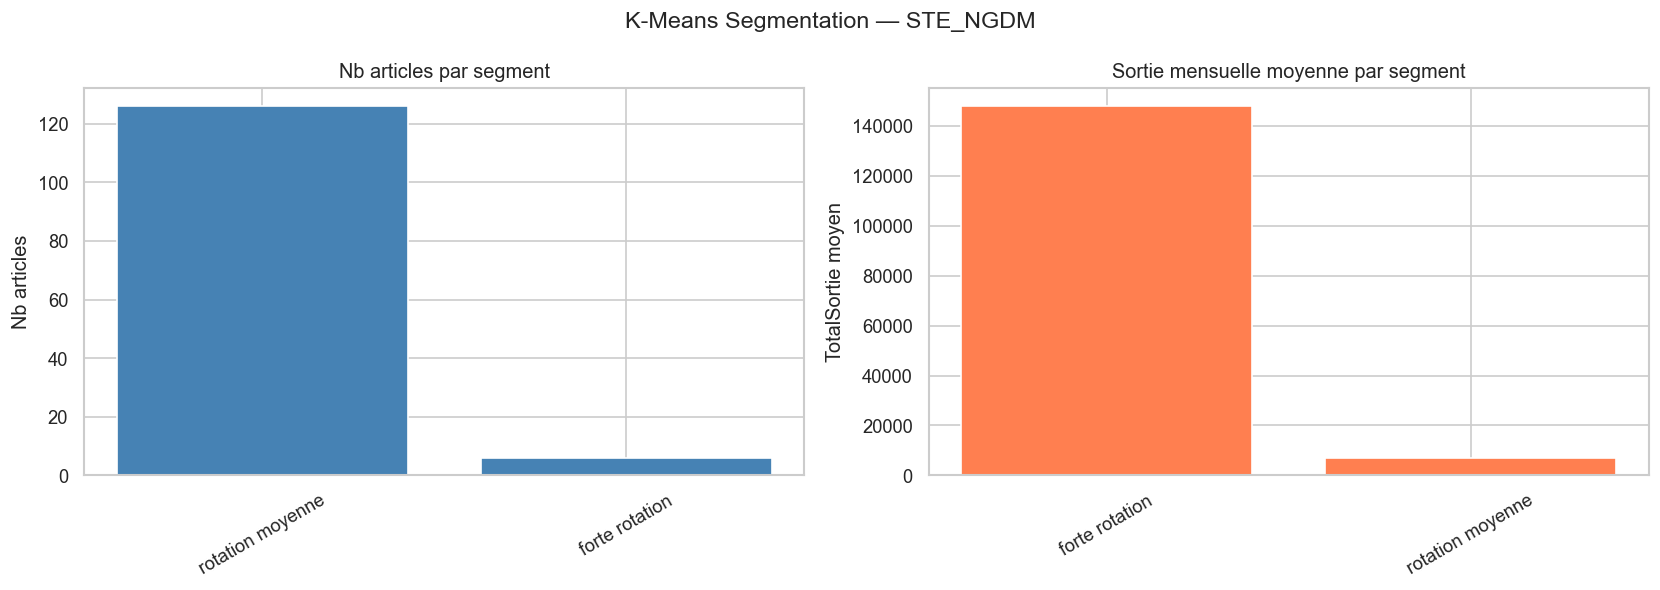

Graphe sauvegardé : kmeans_segments.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'K-Means Segmentation — {BASE_NAME}', fontsize=14)

# ── Nb articles par segment ───────────────────────────────────
seg_counts = df_kmeans_result['segment'].value_counts()
axes[0].bar(seg_counts.index, seg_counts.values, color='steelblue')
axes[0].set_title('Nb articles par segment')
axes[0].set_ylabel('Nb articles')
axes[0].tick_params(axis='x', rotation=30)

# ── Sortie moyenne par segment ────────────────────────────────
# Sélectionner uniquement les colonnes mois avant groupby
cols_mois = [col for col in df_kmeans_result.columns 
             if col not in ['cluster', 'segment']]

seg_means = df_kmeans_result.groupby('segment')[cols_mois]\
    .mean().sum(axis=1)

axes[1].bar(seg_means.index, seg_means.values, color='coral')
axes[1].set_title('Sortie mensuelle moyenne par segment')
axes[1].set_ylabel('TotalSortie moyen')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}kmeans_segments.png", dpi=120, bbox_inches='tight')
plt.show()
print("Graphe sauvegardé : kmeans_segments.png")

In [30]:
# Cellule 14 — Export performances

In [31]:
# ── Prophet ───────────────────────────────────────────────────
df_perf_prophet.to_csv(f"{PERF_DIR}perf_prophet.csv", index=False)

# ── Random Forest ─────────────────────────────────────────────
df_perf_rf = pd.DataFrame([{
    'model' : 'RandomForest',
    'MAE'   : round(mae_rf,  2),
    'RMSE'  : round(rmse_rf, 2),
    'nb_train': len(train_rf),
    'nb_test' : len(test_rf)
}])
df_perf_rf.to_csv(f"{PERF_DIR}perf_rf.csv", index=False)

# ── Isolation Forest ──────────────────────────────────────────
df_perf_if = pd.DataFrame([{
    'model'        : 'IsolationForest',
    'contamination': CONTAMINATION,
    'nb_anomalies' : int(nb_anomalies),
    'pct_anomalies': round(nb_anomalies/len(df_iforest)*100, 2)
}])
df_perf_if.to_csv(f"{PERF_DIR}perf_iforest.csv", index=False)

# ── K-Means ───────────────────────────────────────────────────
df_perf_km = df_kmeans_result['segment'].value_counts()\
    .reset_index().rename(columns={'index':'segment', 'segment':'nb_articles'})
df_perf_km.to_csv(f"{PERF_DIR}perf_kmeans.csv", index=False)

print(f"-Performances exportées dans {PERF_DIR}")
print(f"   perf_prophet.csv")
print(f"   perf_rf.csv")
print(f"   perf_iforest.csv")
print(f"   perf_kmeans.csv")

-Performances exportées dans ../../output/STE_NGDM/performance/
   perf_prophet.csv
   perf_rf.csv
   perf_iforest.csv
   perf_kmeans.csv


In [32]:
# Cellule 15 — Résumé final

In [33]:
print("=" * 60)
print(f"  RÉSUMÉ ENTRAÎNEMENT — {BASE_NAME}")
print("=" * 60)
print(f"""
🔮 AutoARIMA
   Articles entraînés  : {len(df_perf_prophet)}
   MAE moyen           : {df_perf_prophet['MAE'].mean():.1f}
   MAPE moyen          : {df_perf_prophet['MAPE'].dropna().mean():.1f}%

🌲 Random Forest
   MAE                 : {mae_rf:.1f} jours
   RMSE                : {rmse_rf:.1f} jours

🔍 Isolation Forest
   Anomalies détectées : {int(nb_anomalies)} ({nb_anomalies/len(df_iforest)*100:.1f}%)

🎯 K-Means
   k optimal           : {k_optimal}
   Segments            : {list(noms_clusters.values())}

📁 Modèles sauvegardés : {MODEL_DIR}
📁 Performances        : {PERF_DIR}
""")

  RÉSUMÉ ENTRAÎNEMENT — STE_NGDM

🔮 AutoARIMA
   Articles entraînés  : 24
   MAE moyen           : 6.9
   MAPE moyen          : nan%

🌲 Random Forest
   MAE                 : 2.1 jours
   RMSE                : 6.1 jours

🔍 Isolation Forest
   Anomalies détectées : 6409 (5.0%)

🎯 K-Means
   k optimal           : 2
   Segments            : ['forte rotation', 'rotation moyenne']

📁 Modèles sauvegardés : ../../models/STE_NGDM/
📁 Performances        : ../../output/STE_NGDM/performance/

